# 00 - Get Highest Resolution Approximation of a Scene 

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import IPython
from IPython.display import Image, Video
import ipywidgets

import copy
import numpy as np
from glob import glob
import imageio.v3 as iio
import collections

import torch

import torch
from matplotlib.pylab import plt

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.cameras import MiniCam


from src.config import cfg, update_argparser, update_config


PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
DATA_ROOT = os.path.join(PROJECT_ROOT, 'data', '360_v2', 'kitchen')
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, 'output', 'tutorial')
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

DATA_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen
OUTPUT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/output/tutorial


In [ ]:
python ./svraster/train.py \
    --eval \
    --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
    --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03 \
    --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
    --res_downscale 3.5 \
    --n_iter 64000 \
    --init_n_level 5 \
    --adapt_every 4000 \
    --adapt_from 4000 \
    --prune_until 60000 \
    --subdivide_until 60000 \
    --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
                            10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
                            20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
                            30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
                            40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
                            50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
                            60999 61999 62999 63999 \
    --sh_degree_init 0 \
    --sh_degree 0

In [3]:
cfg.merge_from_file(cfg_filename="/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/config.yaml")

In [4]:
# Init and load data pack
data_pack = DataPack(
    source_path=cfg.data.source_path,
    image_dir_name=cfg.data.image_dir_name,
    mask_dir_name=cfg.data.mask_dir_name,
    res_downscale=cfg.data.res_downscale,
    res_width=cfg.data.res_width,
    skip_blend_alpha=cfg.data.skip_blend_alpha,
    alpha_is_white=cfg.model.white_background,
    data_device=cfg.data.data_device,
    use_test=cfg.data.eval,
    test_every=1,
)

# Instantiate data loader
test_cams = data_pack.get_test_cameras()


Read dataset in COLMAP format.
Read dataset in 11.389 seconds.


In [5]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=True,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", 63999)
voxel_model.freeze_vox_geo()

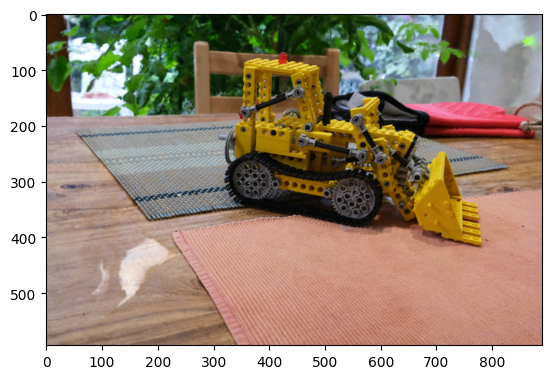

In [6]:
view = test_cams[0]
render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
img_true = torch.permute(view.image, dims=(1, 2, 0)).detach().cpu().numpy()
rendered_img = torch.permute(render_pkg['color'], dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(rendered_img)

In [7]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)



list_num_vox = []
list_psnr = []
list_iters = range(1000, 65000, 1000)
list_imgs = []
view = test_cams[0]
img_true = im_tensor2np(view.image)

for iter in list_iters:
    voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v02", iter)
    voxel_model.freeze_vox_geo()
    render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
    rendered_img = im_tensor2np(render_pkg['color'].detach())
    list_imgs.append(rendered_img)
    
    mse = np.square(img_true/255 - rendered_img/255).mean()
    psnr = -10 * np.log10(mse)
    nvox = voxel_model.num_voxels
    list_psnr.append(psnr)
    list_num_vox.append(nvox)
    print(f"iter = {iter} nvox = {nvox} psnr = {psnr}")



iter = 1000 nvox = 407655 psnr = 18.193382968189546
iter = 2000 nvox = 407655 psnr = 19.342030272785436
iter = 3000 nvox = 407655 psnr = 19.599820499974662
iter = 4000 nvox = 548474 psnr = 19.607984359450064
iter = 5000 nvox = 548474 psnr = 20.944005020978334
iter = 6000 nvox = 548474 psnr = 21.066747748492567
iter = 7000 nvox = 548474 psnr = 21.485191760844586
iter = 8000 nvox = 530278 psnr = 21.382810640148623
iter = 9000 nvox = 530278 psnr = 22.218015003761366
iter = 10000 nvox = 530278 psnr = 22.517651132477148
iter = 11000 nvox = 530278 psnr = 22.414614959912797
iter = 12000 nvox = 351120 psnr = 22.37045911397508
iter = 13000 nvox = 351120 psnr = 23.36308515843324
iter = 14000 nvox = 351120 psnr = 22.848765105889683
iter = 15000 nvox = 351120 psnr = 23.46311259790641
iter = 16000 nvox = 430662 psnr = 22.820094242431562
iter = 17000 nvox = 430662 psnr = 22.88395078442282
iter = 18000 nvox = 430662 psnr = 23.41791346522422
iter = 19000 nvox = 430662 psnr = 23.1064975597845
iter = 20

/tmp/ipykernel_17634/3133911865.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


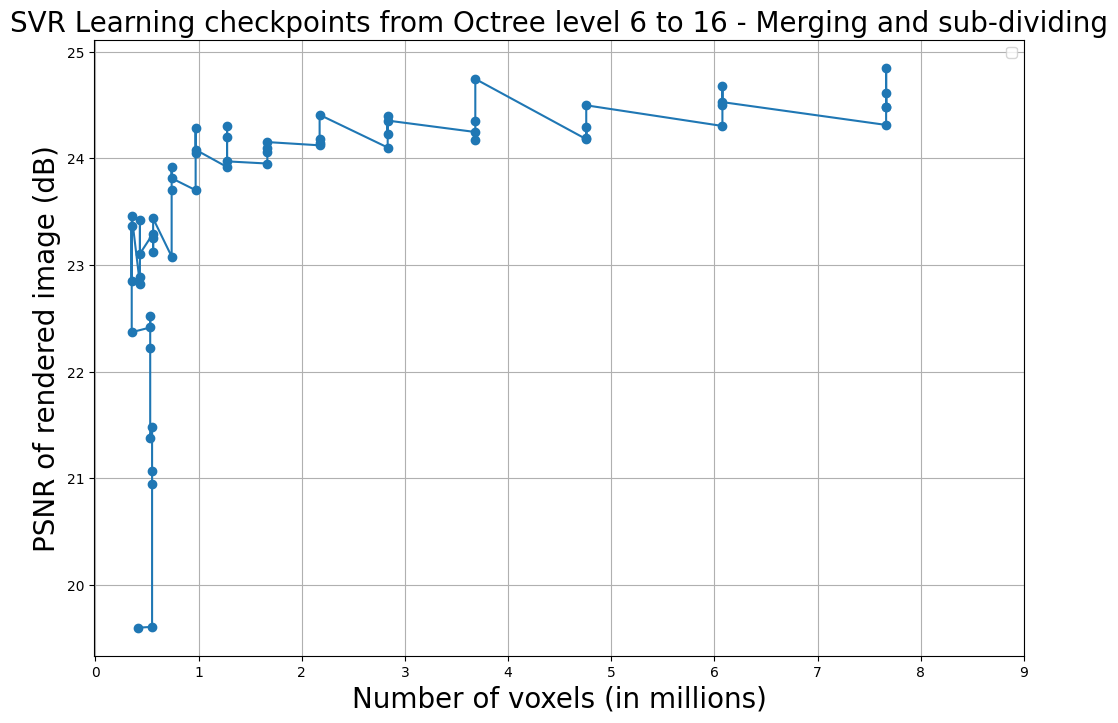

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_num_vox[2:])/1e6, list_psnr[2:], "o-")
ax.set_ylabel("PSNR of rendered image (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

plt.title("SVR Learning checkpoints from Octree level 6 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)



list_num_vox = collections.OrderedDict()
list_psnr = collections.OrderedDict()
list_imgs = collections.OrderedDict()
list_iters = range(1000, 65000, 1000)
view = test_cams[0]
img_true = im_tensor2np(view.image)

for iter in list_iters:
    voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v02", iter)
    voxel_model.freeze_vox_geo()
    render_pkg = voxel_model.render(view, output_depth=False, output_normal=False, output_T=False)
    rendered_img = im_tensor2np(render_pkg['color'].detach())


    mse = np.square(img_true/255 - rendered_img/255).mean()
    psnr = -10 * np.log10(mse)
    nvox = voxel_model.num_voxels
    if (nvox in list_psnr) and list_psnr[nvox] <= psnr:
        list_psnr[nvox] = psnr
        list_num_vox[nvox] = iter
        list_imgs[nvox] = rendered_img
    elif (nvox not in list_psnr) :
        list_psnr[nvox] = psnr
        list_num_vox[nvox] = iter
        list_imgs[nvox] = rendered_img
    print(f"iter = {iter} nvox = {nvox} psnr = {psnr}")



iter = 1000 nvox = 407655 psnr = 18.380043858090573
iter = 2000 nvox = 407655 psnr = 19.309213535130134
iter = 3000 nvox = 407655 psnr = 19.57396080230219
iter = 4000 nvox = 548474 psnr = 19.602375371247675
iter = 5000 nvox = 548474 psnr = 20.939007712206376
iter = 6000 nvox = 548474 psnr = 21.066598832462535
iter = 7000 nvox = 548474 psnr = 21.484404574422193
iter = 8000 nvox = 530278 psnr = 21.37769116578066
iter = 9000 nvox = 530278 psnr = 22.212896659697684
iter = 10000 nvox = 530278 psnr = 22.512221240616515
iter = 11000 nvox = 530278 psnr = 22.404116654442188
iter = 12000 nvox = 351120 psnr = 22.42935829010711
iter = 13000 nvox = 351120 psnr = 23.50534409485337
iter = 14000 nvox = 351120 psnr = 22.935207183092672
iter = 15000 nvox = 351120 psnr = 23.58442702933491
iter = 16000 nvox = 430662 psnr = 22.984198871692243
iter = 17000 nvox = 430662 psnr = 23.043172795746365
iter = 18000 nvox = 430662 psnr = 23.567915642755175
iter = 19000 nvox = 430662 psnr = 23.24428373337197
iter = 2

/tmp/ipykernel_445555/3398002771.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


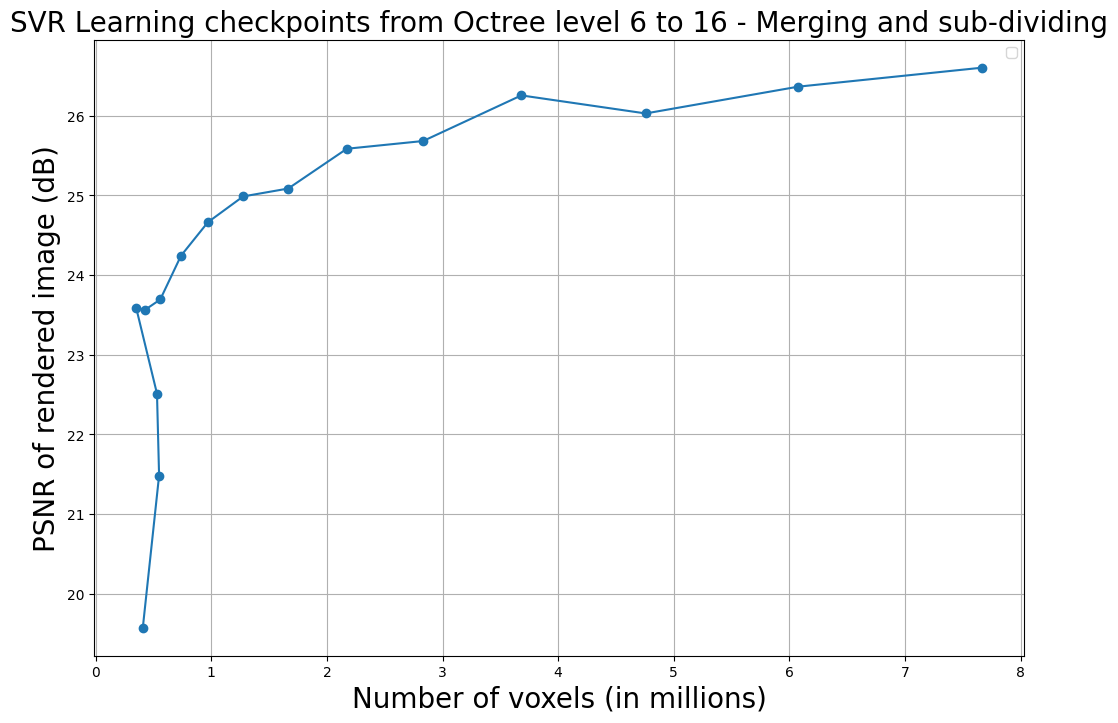

In [14]:
list_vox_best, list_psnr_best = np.array([k for k, v in list_psnr.items()]), np.array([v for k, v in list_psnr.items()])


fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_vox_best)/1e6, list_psnr_best, "o-")
ax.set_ylabel("PSNR of rendered image (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

plt.title("SVR Learning checkpoints from Octree level 6 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

In [15]:
list_vox_best, list_img_best = np.array([k for k, v in list_imgs.items()]), np.array([v for k, v in list_imgs.items()])
len(list_img_best)

16

/tmp/ipykernel_445555/1596807548.py:2: UserWarning: The figure layout has changed to tight
  fig.tight_layout(h_pad=-30.0)


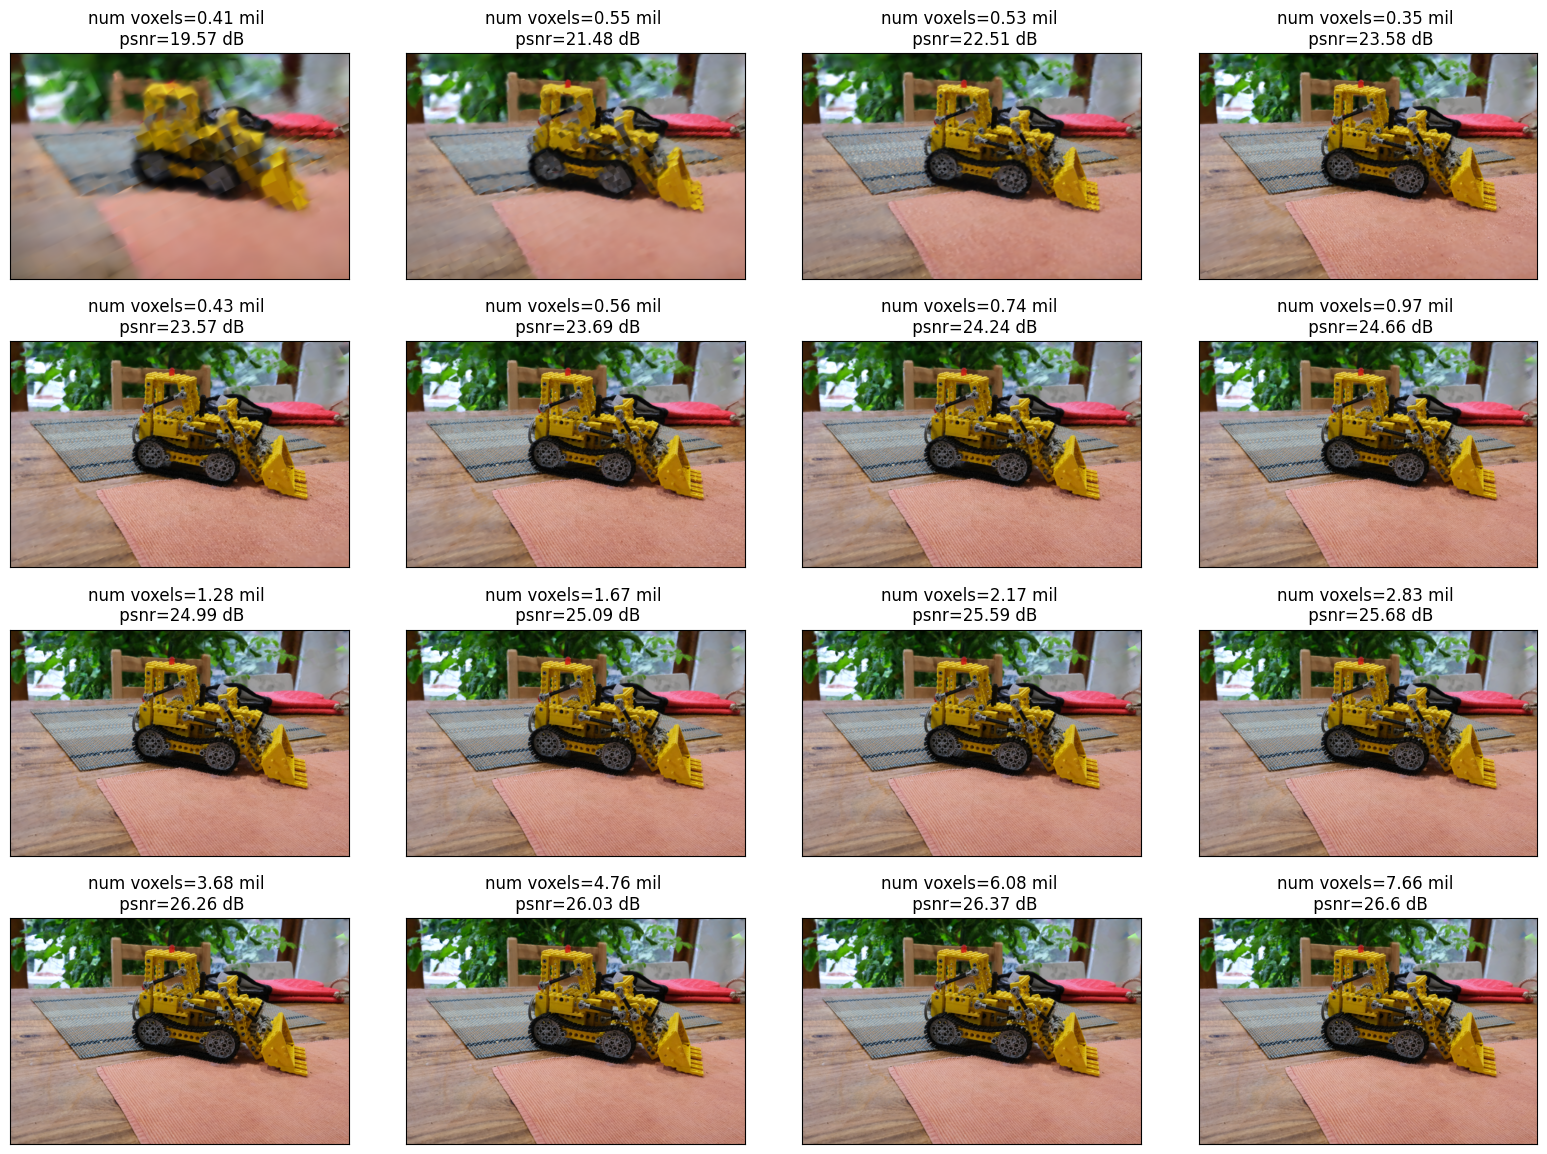

In [16]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(16, 16), constrained_layout=True)
fig.tight_layout(h_pad=-30.0)
i = 0
for nvox, img_best in list_imgs.items():
    ax[i//4][i%4].imshow(img_best)
    ax[i//4][i%4].xaxis.set_visible(False)
    ax[i//4][i%4].yaxis.set_visible(False)
    ax[i//4][i%4].set_title(f"num voxels={np.round(nvox/1e6, 2)} mil \n psnr={np.round(list_psnr[nvox], 2)} dB")
    i+=1
plt.show()


In [9]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=False,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v02", 64000)
voxel_model.freeze_vox_geo()

In [10]:
voxel_model.shs

tensor([[[0., 0., 0.]],

        [[0., 0., 0.]],

        [[0., 0., 0.]],

        ...,

        [[0., 0., 0.]],

        [[0., 0., 0.]],

        [[0., 0., 0.]]], device='cuda:0', requires_grad=True)

In [12]:
voxel_model.vox_center, voxel_model.vox_size

(tensor([[-3.4819,  0.6685,  5.3019],
         [-3.2546,  0.4412, 14.1674],
         [-3.2546,  1.3505, 14.1674],
         ...,
         [-3.7128,  2.9169,  0.4820],
         [-3.7128,  2.9240,  0.4749],
         [-3.7128,  2.9240,  0.4820]], device='cuda:0'),
 tensor([[0.4546],
         [0.9093],
         [0.9093],
         ...,
         [0.0071],
         [0.0071],
         [0.0071]], device='cuda:0'))